In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
import re
import string


In [2]:

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AMD\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\AMD\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [7]:
df = pd.read_csv(r"C:\Users\AMD\OneDrive\Desktop\NLP_AU\IMDB Dataset.csv")

In [8]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None


In [10]:
print(df.shape)

(50000, 2)


In [11]:
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


In [12]:
df.sentiment.value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [13]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [14]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'<.*?>',' ',text)

    text = re.sub(r'http\S+',' ',text)

    text = re.sub(r'[^a-zA-Z]',' ',text)

    words = text.split()

    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

In [16]:
df['clean_review'] = df['review'].apply(clean_text)

In [17]:
X = df['clean_review']

y = df['sentiment']

In [18]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
model = Pipeline([
    ('tfidf',TfidfVectorizer(max_features=10000)),
    ('classifier',LogisticRegression(max_iter=1000))
])

In [20]:
model.fit(X_train,y_train)

,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [21]:
prediction=model.predict(X_test)

In [22]:
accuracy=accuracy_score(y_test,prediction)

print("Accuracy =",accuracy)

Accuracy = 0.8946


In [23]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

    negative       0.91      0.88      0.89      4961
    positive       0.88      0.91      0.90      5039

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [24]:
cm=confusion_matrix(y_test,prediction)

print(cm)

[[4354  607]
 [ 447 4592]]


In [25]:
reviews=[
"The movie was outstanding and emotional",

"I wasted my money watching this",

"Excellent acting and amazing music",

"The story was boring",

"It was okay."
]

result=model.predict(reviews)

for r,s in zip(reviews,result):
    print(r)
    print("Prediction:",s)
    print()

The movie was outstanding and emotional
Prediction: positive

I wasted my money watching this
Prediction: negative

Excellent acting and amazing music
Prediction: positive

The story was boring
Prediction: negative

It was okay.
Prediction: negative



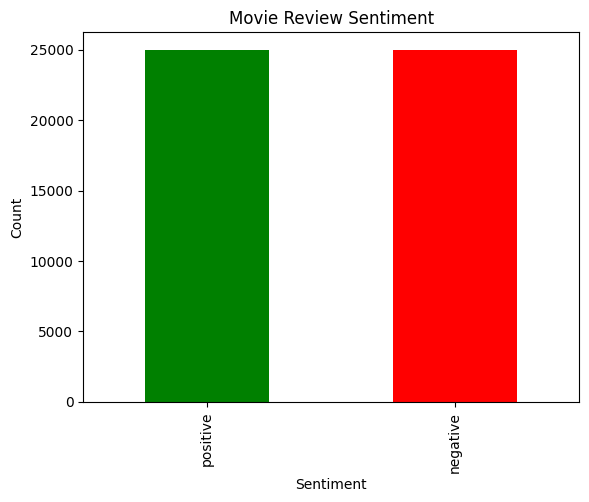

In [26]:
df['sentiment'].value_counts().plot(
    kind='bar',
    color=['green','red']
)

plt.title("Movie Review Sentiment")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

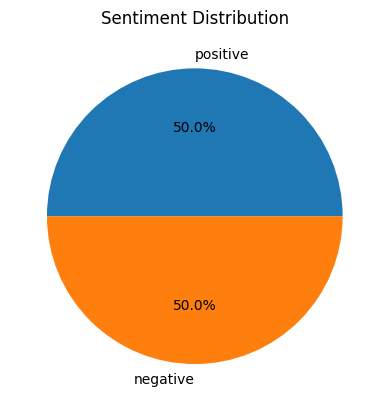

In [27]:
df['sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title("Sentiment Distribution")

plt.show()